# ONERA 468 CRM Data Exploration

End-to-end notebook for the ONERA 468 CRM Codabench challenge.
Covers: data loading, train/test split visualization, 3-D density field
rendering, KNN baseline training, extended error metrics, and residual
KL-divergence analysis.

## 1. Imports

In [6]:
#srun --account=tau --partition=gpu-best --nodes=1 --ntasks=1 --cpus-per-task=10 --gres=gpu:1 --mem=64G --time=18:00:00 --pty bash

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, entropy
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler


## 2. Global Constants

Column indices into the 9-feature input array and mesh-level constants
shared across all analysis sections.

In [3]:
nwallp           = 260774   # wall points per simulation
COL_MINF         = 6        # Mach number column
COL_AOA          = 7        # angle of attack column
COL_PI           = 8        # tunnel pressure ratio column
GRAD_PERCENTILE  = 95       # percentile threshold for shock-zone detection
SHOCK_NEIGHBOR_K = 6        # k-NN order for local gradient estimation
OUTPUT_DIR       = '../output/'
DATA_DIR         = '/data/tau/iceberg_1/shared/ochabane/FILES_RHO_ALL_POINTS_reduitfloat32/'


## 6. KNN Baseline: Phase 1 & 2 Evaluation

Loads train and test arrays for both Codabench phases, trains a 5-NN regressor
on (Mach, AoA, Pi) condition vectors, and predicts the density field for each phase.

In [4]:
print('Loading data...')
X_train = np.load(DATA_DIR + 'splitv2/train_data.npy')
y_train = np.load(DATA_DIR + 'splitv2/train_labels.npy')
X_test1 = np.load(DATA_DIR + 'splitv2/test_phase1_data.npy')
y_test1 = np.load(DATA_DIR+'splitv2/test_phase1_labels.npy')
X_test2 = np.load(DATA_DIR + 'splitv2/test_phase2_data.npy')
y_test2 = np.load(DATA_DIR+'splitv2/test_phase2_labels.npy')

train_conds = X_train[::nwallp, COL_MINF:COL_PI+1]
test1_conds = X_test1[::nwallp, COL_MINF:COL_PI+1]
test2_conds = X_test2[::nwallp, COL_MINF:COL_PI+1]

n_train = X_train.shape[0] // nwallp
n_test1 = X_test1.shape[0] // nwallp
n_test2 = X_test2.shape[0] // nwallp

test1_weights = np.where(np.abs(test1_conds[:, 1]) < 10.0, 1.0, 0.5)
test2_weights = np.where(np.abs(test2_conds[:, 1]) < 10.0, 1.0, 0.5)

scaler         = StandardScaler()
train_conds_sc = scaler.fit_transform(train_conds)
test1_conds_sc = scaler.transform(test1_conds)
test2_conds_sc = scaler.transform(test2_conds)

print('Training KNN...')
knn = KNeighborsRegressor(n_neighbors=5, algorithm='auto', n_jobs=-1)
knn.fit(train_conds_sc, y_train.reshape(n_train, nwallp))

print('Predicting phase 1...')
y_pred1 = knn.predict(test1_conds_sc).reshape(-1)
print('Predicting phase 2...')
y_pred2 = knn.predict(test2_conds_sc).reshape(-1)


Loading data...
Training KNN...
Predicting phase 1...
Predicting phase 2...


## 7. Component Metrics: wrMAE, R2, Weighted KL

Loads component labels and, per phase, computes per-simulation wrMAE, R2
and a component-weighted KL score together. The weighted KL replaces a single
global score with a weighted sum of per-component `residual_kl_normal` scores:
wing=0.3, pylon=0.3, fuselage=0.2, nacelle=0.2.

In [5]:
component_labels = np.load(DATA_DIR + 'component_labels_unique.npy')
with open(DATA_DIR + 'component_map.json') as f:
    component_map = {int(k): v for k, v in json.load(f).items()}

KL_WEIGHTS = {'wing': 0.3, 'pylon': 0.3, 'fuselage': 0.2, 'nacelle': 0.2}
comp_masks = {cname: component_labels == cid for cid, cname in component_map.items()}


## 8. Residual KL-Divergence

`residual_kl_normal` measures how close the residual distribution is to a narrow
reference Gaussian N(0, 0.1*sigma_y), a proxy for perfect prediction.
score = 1/(1+KL) in (0, 1]; higher is better.

In [ ]:
# These are different methods of computing KL div, the one we used is: ```residual_kl_weighted```
def residual_kl_dirac(y_true, y_pred, sigma_ref_frac=0.01, n_bins=200):
    """
    KL(p_eps || N(0, sigma_ref)) where sigma_ref is very small (proxy for Dirac(0)).
    Returns KL, score=exp(-KL), normalised bias and spread.
    """
    eps      = y_pred - y_true
    sigma_y  = y_true.std() + 1e-12
    eps_norm = eps / sigma_y
    sigma_ref = sigma_ref_frac

    bins = np.linspace(-5.0, 5.0, n_bins + 1)
    dx   = bins[1] - bins[0]
    p, _ = np.histogram(eps_norm, bins=bins, density=True)
    p    = np.clip(p * dx, 1e-10, None)
    p   /= p.sum()

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    q    = norm.pdf(bin_centers, loc=0.0, scale=sigma_ref)
    q    = np.clip(q, 1e-10, None)
    q   /= q.sum()

    kl    = float(entropy(p, q))
    return {'kl': kl, 'score': float(np.exp(-kl)),
            'bias': float(np.mean(eps_norm)), 'spread': float(np.std(eps_norm))}


def residual_kl_normal(y_true, y_pred, sigma_ref_frac=0.1, n_bins=200):
    """
    KL(p_eps || N(0, sigma_ref)) where sigma_ref = sigma_ref_frac * sigma_y.
    Returns KL, score=exp(-KL), normalised bias and spread.
    """
    eps       = y_pred - y_true
    sigma_y   = y_true.std() + 1e-12
    sigma_ref = sigma_ref_frac * sigma_y

    lim  = 5.0 * sigma_y
    bins = np.linspace(-lim, lim, n_bins + 1)
    dx   = bins[1] - bins[0]
    p, _ = np.histogram(eps, bins=bins, density=True)
    p    = np.clip(p * dx, 1e-10, None)
    p   /= p.sum()

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    q    = norm.pdf(bin_centers, loc=0.0, scale=sigma_ref) * dx
    q    = np.clip(q, 1e-10, None)
    q   /= q.sum()

    kl    = float(entropy(p, q))
    return {'kl': kl, 'score': float(np.exp(-kl)),
            'bias': float(np.mean(eps) / sigma_y), 'spread': float(np.std(eps) / sigma_y)}

def residual_kl_weighted(y_true, y_pred, comp_masks, comp_weights, sigma_ref_frac=0.1, n_bins=200):
    """
    KL(p_eps || N(0, sigma_ref)) on residuals pooled across components,
    with each point weighted by its component weight (so wing/pylon points
    count more than fuselage/nacelle points in the SAME histogram).
    Single shared sigma_y -> comparable across all simulations.
    """
    eps      = y_pred - y_true
    sigma_y  = y_true.std() + 1e-12
    sigma_ref = sigma_ref_frac * sigma_y

    sample_weight = np.zeros_like(eps)
    for cname, mask in comp_masks.items():
        sample_weight[mask] = comp_weights.get(cname, 0.0)

    lim  = 5.0 * sigma_y
    bins = np.linspace(-lim, lim, n_bins + 1)
    dx   = bins[1] - bins[0]

    p, _ = np.histogram(eps, bins=bins, weights=sample_weight, density=True)
    p    = np.clip(p * dx, 1e-10, None)
    p   /= p.sum()

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    q = norm.pdf(bin_centers, loc=0.0, scale=sigma_ref) * dx
    q = np.clip(q, 1e-10, None)
    q /= q.sum()

    kl = float(entropy(p, q))
    bias   = float(np.average(eps, weights=sample_weight)) / sigma_y
    spread = float(np.sqrt(np.average((eps - eps.mean())**2, weights=sample_weight))) / sigma_y
    return {'kl': kl, 'score': float(np.exp(-kl)), 'bias': bias, 'spread': spread}


In [ ]:
def evaluate_phase(y, y_pred, weights, n_sims, nwallp):
    """Per-simulation wrMAE, R2, component wrMAE/R2, and frequency-weighted KL."""
    Y, Yh = y.reshape(n_sims, nwallp), y_pred.reshape(n_sims, nwallp)
    relMAE, r2, kl_w = np.full(n_sims, np.nan), np.full(n_sims, np.nan), np.full(n_sims, np.nan)
    comp_relMAE = {c: np.full(n_sims, np.nan) for c in KL_WEIGHTS}
    comp_r2     = {c: np.full(n_sims, np.nan) for c in KL_WEIGHTS}
    comp_kl     = {c: [None] * n_sims for c in KL_WEIGHTS}

    for i in range(n_sims):
        if weights[i] < 1.0:
            continue
        yc, yhatc = Y[i], Yh[i]
        relMAE[i] = np.mean(np.abs(yc - yhatc)) / np.mean(np.abs(yc))
        r2[i]     = 1.0 - np.sum((yc - yhatc)**2) / np.sum((yc - yc.mean())**2)

        for cname, mask in comp_masks.items():
            if cname not in KL_WEIGHTS:
                continue
            ycm, yhatcm = yc[mask], yhatc[mask]
            comp_relMAE[cname][i] = np.mean(np.abs(ycm - yhatcm)) / np.mean(np.abs(ycm))
            comp_r2[cname][i]     = 1.0 - np.sum((ycm - yhatcm)**2) / np.sum((ycm - ycm.mean())**2)
            comp_kl[cname][i] = residual_kl_normal(ycm, yhatcm)

        kl_w[i] = residual_kl_weighted(yc, yhatc, comp_masks, KL_WEIGHTS)['kl']

    return dict(Y=Y, Yh=Yh, relMAE=relMAE, r2=r2, kl=kl_w,
                comp_relMAE=comp_relMAE, comp_r2=comp_r2, comp_kl=comp_kl)


res1 = evaluate_phase(y_test1, y_pred1, test1_weights, n_test1, nwallp)
res2 = evaluate_phase(y_test2, y_pred2, test2_weights, n_test2, nwallp)

#===================================
def print_phase_summary(label, res):
    i_mae = int(np.nanargmax(res['relMAE']))
    print(f'\n{label}')
    print(f'  sim {i_mae}  wrMAE={res["relMAE"][i_mae]:.4f}  R2={res["r2"][i_mae]:.4f}  KL_weighted={res["kl"][i_mae]:.4f} score={float(np.exp(-res["kl"][i_mae])):.4f}')

    def table(title, comp_dict, fmt):
        print(f'\n  {title}')
        print(f'  {"component":<10}  {"mean":>9}  {"max":>9}')
        print(f'  {"─"*10}  {"─"*9}  {"─"*9}')
        for cname in KL_WEIGHTS:
            vals = comp_dict[cname]
            vals = vals[~np.isnan(vals)] if vals.dtype != object else vals
            print(f'  {cname:<10}  {np.nanmean(vals):>9{fmt}}  {np.nanmax(vals):>9{fmt}}')

    table('wrMAE by component', res['comp_relMAE'], '.4f')
    table('R2 by component',    res['comp_r2'],     '.4f')

    print(f'\n  KL by component')
    print(f'  {"component":<10}  {"mean KL":>9}  {"max KL":>9}  {"mean score":>10}  {"mean bias":>10}  {"mean spread":>11}')
    print(f'  {"─"*10}  {"─"*9}  {"─"*9}  {"─"*10}  {"─"*10}  {"─"*11}')
    for cname in KL_WEIGHTS:
        vals = [v for v in res['comp_kl'][cname] if v is not None]
        kl_c, sc_c, bi_c, sp_c = (np.array([v[k] for v in vals]) for k in ('kl', 'score', 'bias', 'spread'))
        print(f'  {cname:<10}  {kl_c.mean():>9.4f}  {kl_c.max():>9.4f}  '
              f'{sc_c.mean():>10.4f}  {bi_c.mean():>10.4f}  {sp_c.mean():>11.4f}')


for label, res in [('Phase 1', res1), ('Phase 2', res2)]:
    print_phase_summary(label, res)


Phase 1
  sim 131  wrMAE=0.0340  R2=0.9419  KL_weighted=1.4315 score=0.2390

  wrMAE by component
  component        mean        max
  ──────────  ─────────  ─────────
  wing           0.0338     0.0623
  pylon          0.0260     0.0719
  fuselage       0.0107     0.0266
  nacelle        0.0141     0.0264

  R2 by component
  component        mean        max
  ──────────  ─────────  ─────────
  wing           0.9384     0.9848
  pylon          0.9205     0.9930
  fuselage       0.9620     0.9943
  nacelle        0.9891     0.9979

  KL by component
  component     mean KL     max KL  mean score   mean bias  mean spread
  ──────────  ─────────  ─────────  ──────────  ──────────  ───────────
  wing           1.4255     3.3066      0.2919     -0.0437       0.2303
  pylon          2.0752     7.3031      0.2341     -0.1183       0.2215
  fuselage       0.9295     3.2745      0.4582     -0.0508       0.1670
  nacelle        0.4118     0.8356      0.6720      0.0054       0.0995

Phase 2
  

## 9. Worst-Condition Plots (Same Error Scale) and Worst-KL Histograms

3-D scatter of ground truth / prediction / absolute error for the worst-wrMAE
and worst-weighted-KL simulation in each phase, plus the true pointwise mean field
across all simulations (mean of y and y_pred at each of the nwallp points).
Error plots share one color scale across both phases for direct comparison.
Residual histograms per body part are shown for the worst-KL simulation.

Saved: worst_condition_Phase_1_worst_wrMAE.png


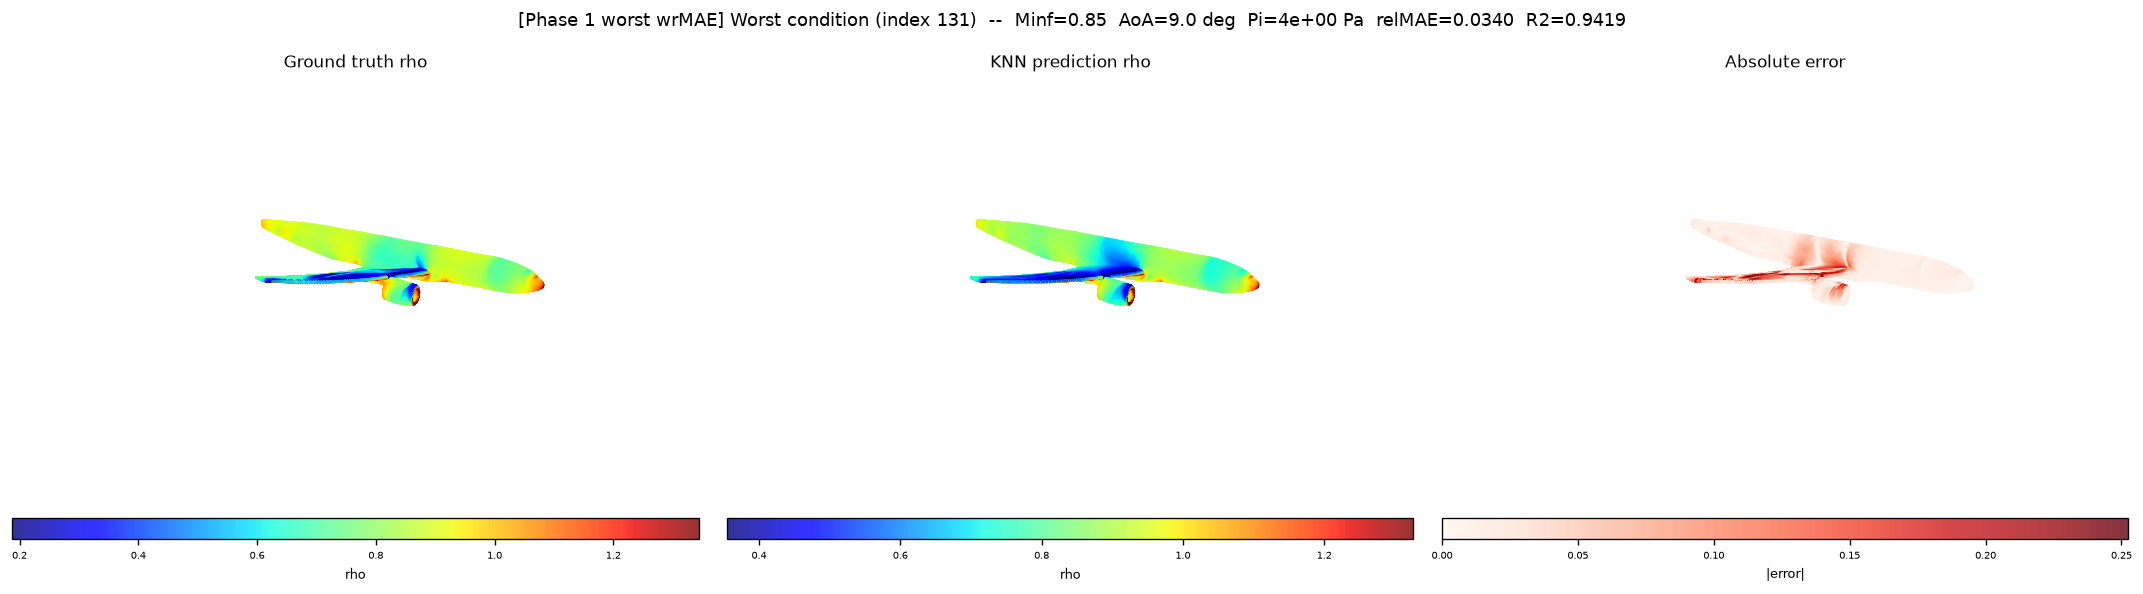

Saved: worst_condition_Phase_1_worst_KL.png


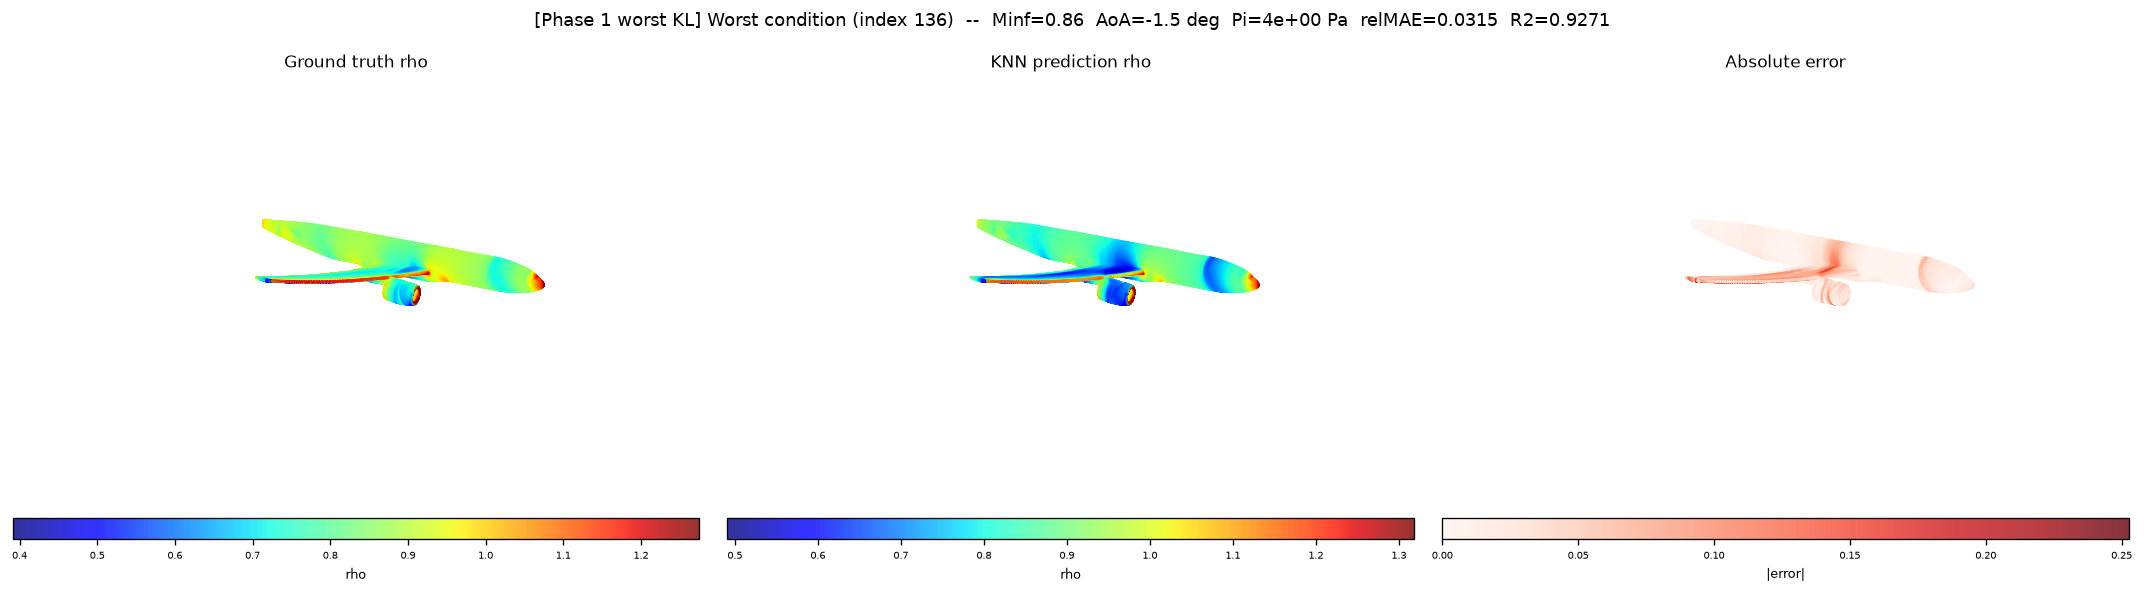

Saved: worst_condition_Phase_2_worst_wrMAE.png


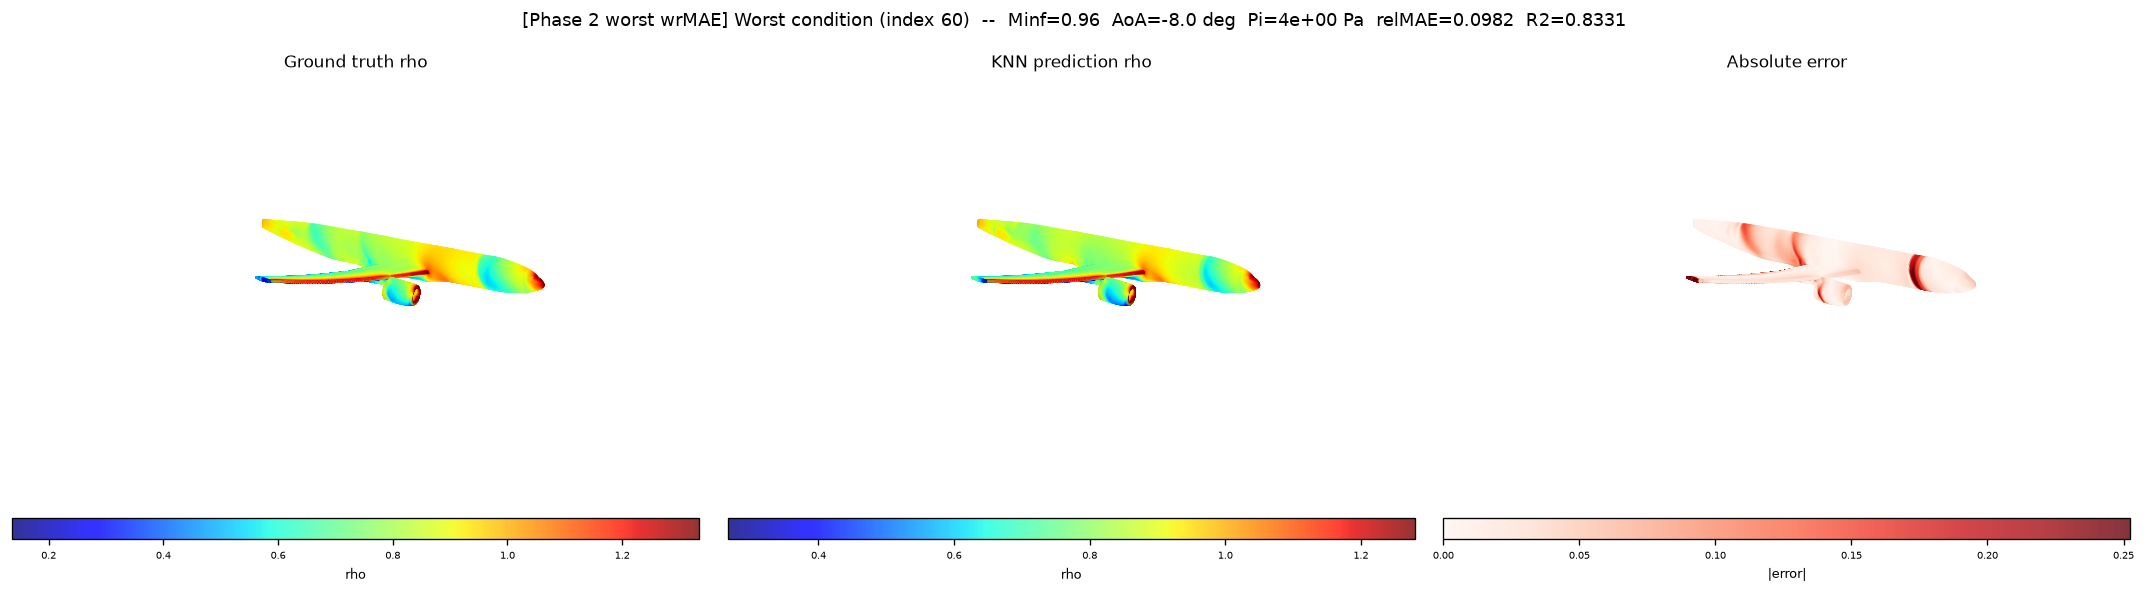

Saved: worst_condition_Phase_2_worst_KL.png


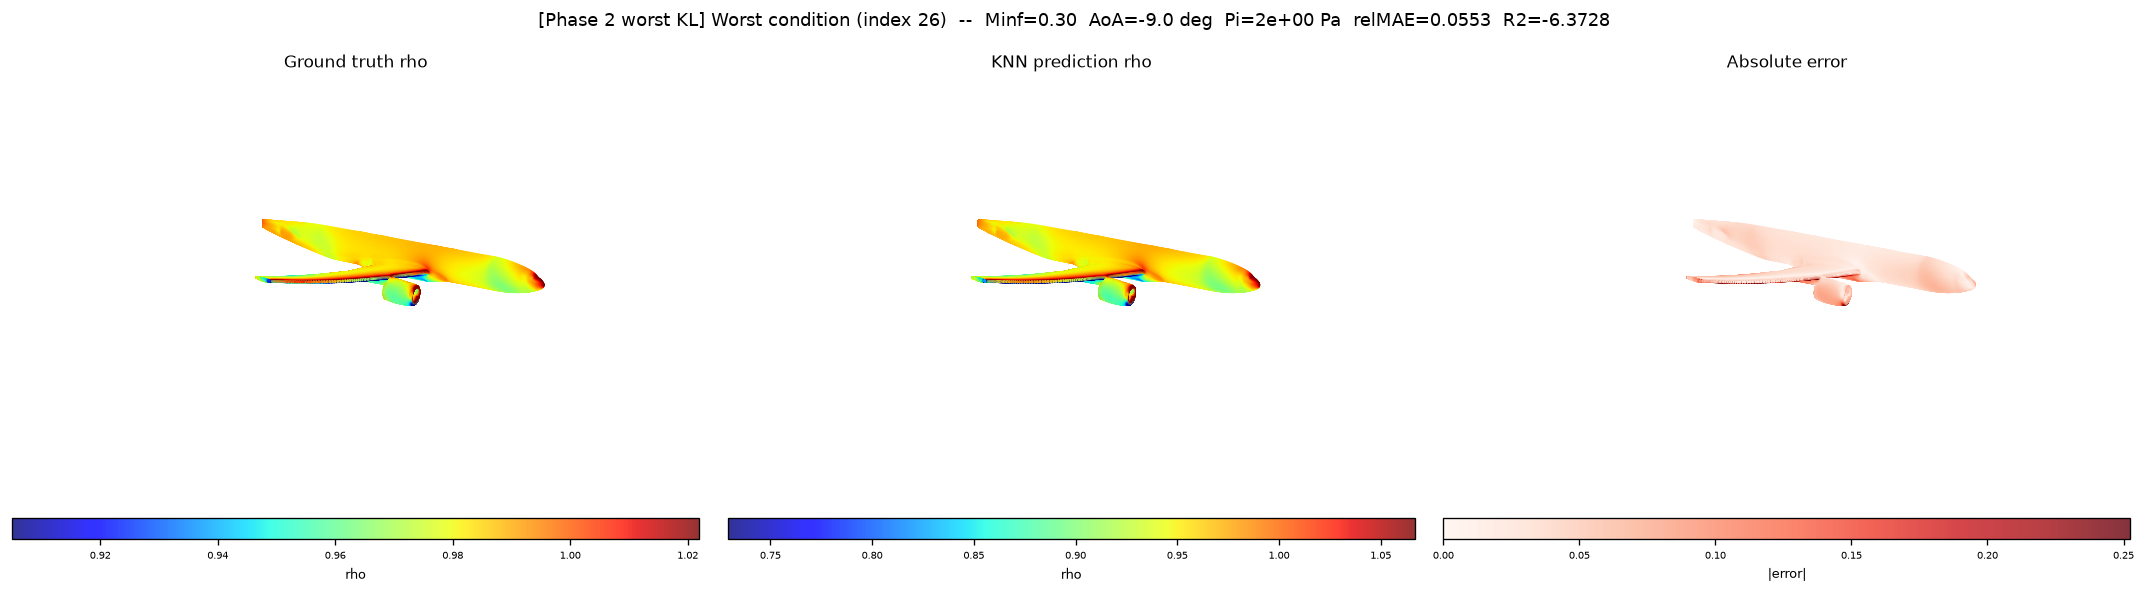

In [8]:
def plot_condition(iworst, X_test, y_test, y_pred, nwallp, wrMAE, phase_label, r2=None, err_vmax=None):
    """3-D scatter of ground truth, prediction and absolute error for one simulation."""
    X_worst    = X_test [iworst * nwallp:(iworst + 1) * nwallp]
    y_worst    = y_test [iworst * nwallp:(iworst + 1) * nwallp]
    yhat_worst = y_pred [iworst * nwallp:(iworst + 1) * nwallp]

    Minf = X_worst[0, COL_MINF]
    AoA  = X_worst[0, COL_AOA]
    Pi   = X_worst[0, COL_PI]

    X_coord = X_worst[:, 0]
    Y_coord = X_worst[:, 1]
    Z_coord = X_worst[:, 2]
    error   = np.abs(y_worst - yhat_worst)

    def _scale(field):
        f03, f50, f97 = np.percentile(field, [3., 50., 97.])
        slopem = (f50 - f03) / 0.47
        slopep = (f97 - f50) / 0.47
        return max(0., f50 - 0.6 * slopem), f50 + 0.6 * slopep

    fields = [y_worst, yhat_worst, error]
    titles = ['Ground truth rho', 'KNN prediction rho', 'Absolute error']
    cmaps  = ['jet', 'jet', 'Reds']

    r2_str = f'  R2={r2:.4f}' if r2 is not None else ''
    fig = plt.figure(figsize=(18, 5), dpi=120)
    fig.suptitle(
        f'[{phase_label}] Worst condition (index {iworst})  --  '
        f'Minf={Minf:.2f}  AoA={AoA:.1f} deg  Pi={Pi:.0e} Pa  relMAE={wrMAE:.4f}{r2_str}',
        fontsize=11
    )
    for col, (field, title, cmap) in enumerate(zip(fields, titles, cmaps)):
        gs  = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[20, 1])
        ax  = fig.add_subplot(gs[0, col], projection='3d')
        fmin, fmax = _scale(field)
        if col == 2 and err_vmax is not None:
            fmin, fmax = 0.0, err_vmax
        sca = ax.scatter3D(X_coord, Y_coord, Z_coord,
                           c=field, vmin=fmin, vmax=fmax,
                           cmap=cmap, s=0.3, alpha=0.8)
        ax.view_init(elev=20, azim=120)
        ax.set_xlim(X_coord.min() - 5.0, X_coord.max() + 5.0)
        ax.set_ylim(Y_coord.min() - 5.0, Y_coord.max() + 5.0)
        ax.set_zlim(Z_coord.min(), Z_coord.max())
        lims = np.array([getattr(ax, f'get_{a}lim')() for a in 'xyz'])
        ax.set_box_aspect(np.ptp(lims, axis=1), zoom=1.)
        ax.set_axis_off()
        ax.set_title(title, fontsize=10)
        cax  = fig.add_subplot(gs[1, col])
        cbar = fig.colorbar(sca, cax=cax, orientation='horizontal')
        cbar.set_label('rho' if col < 2 else '|error|', size=8)
        cbar.ax.tick_params(labelsize=6)
    plt.tight_layout()
    out = f'worst_condition_{phase_label.replace(" ", "_")}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()


err_vmax = max(
    np.percentile(np.abs(res1['Y'][int(np.nanargmax(res1['relMAE']))] -
                          res1['Yh'][int(np.nanargmax(res1['relMAE']))]), 97),
    np.percentile(np.abs(res2['Y'][int(np.nanargmax(res2['relMAE']))] -
                          res2['Yh'][int(np.nanargmax(res2['relMAE']))]), 97),
)

for label, X_test, res in [('Phase 1', X_test1, res1), ('Phase 2', X_test2, res2)]:
    iw_mae = int(np.nanargmax(res['relMAE']))
    iw_kl  = int(np.nanargmax(res['kl']))

    plot_condition(iw_mae, X_test, res['Y'].reshape(-1), res['Yh'].reshape(-1), nwallp,
                   res['relMAE'][iw_mae], f'{label} worst wrMAE', r2=res['r2'][iw_mae], err_vmax=err_vmax)
    plot_condition(iw_kl, X_test, res['Y'].reshape(-1), res['Yh'].reshape(-1), nwallp,
                   res['relMAE'][iw_kl], f'{label} worst KL', r2=res['r2'][iw_kl], err_vmax=err_vmax)